Slope: 6.36
Intercept: 33.80
Root Mean Square Error (RMSE): 6.84
R² Score: 0.97


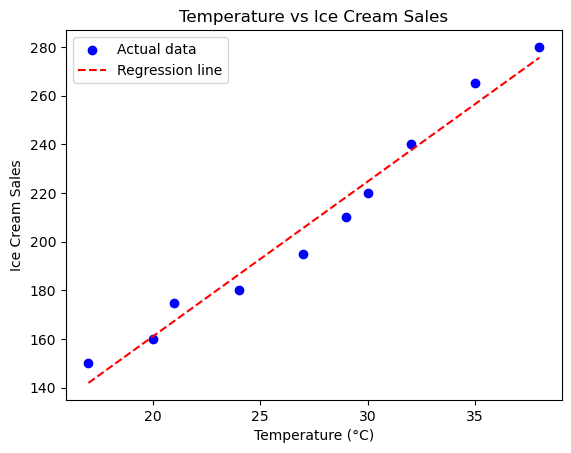

In [2]:
#Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Data: Temperature vs Ice Cream Sales
temperature = np.array([17, 20, 21, 24, 27, 29, 30, 32, 35, 38]).reshape(-1, 1)
sales = np.array([150, 160, 175, 180, 195, 210, 220, 240, 265, 280])

# Create a linear regression model
model = LinearRegression()
model.fit(temperature, sales)

# Make predictions
predicted_sales = model.predict(temperature)

# Calculate slope, intercept, RMSE, and R² score
slope = model.coef_[0]
intercept = model.intercept_
rmse = np.sqrt(mean_squared_error(sales, predicted_sales))
r2 = r2_score(sales, predicted_sales)

# Print the values
print(f"Slope: {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print(f"Root Mean Square Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

# Plot scatterplot and regression line
plt.scatter(temperature, sales, color='blue', label="Actual data")
plt.plot(temperature, predicted_sales, color='red', linestyle="dashed", label="Regression line")

plt.xlabel("Temperature (°C)")
plt.ylabel("Ice Cream Sales")
plt.title("Temperature vs Ice Cream Sales")
plt.legend()
plt.show()


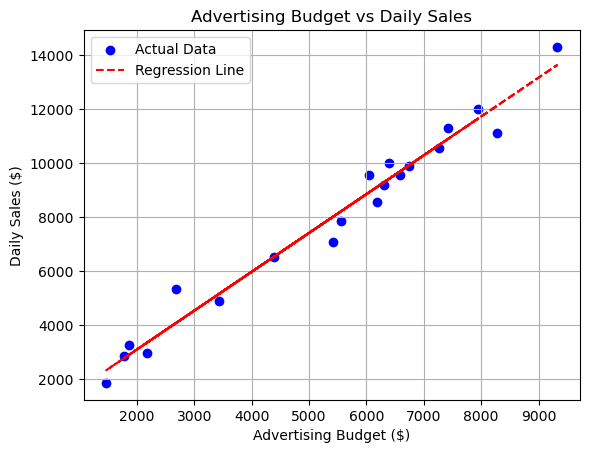

Linear Regression Equation: y = 1.44x + 219.28
R-squared: 0.974
RMSE: 549.248


In [2]:
#Import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Generate random dataset
np.random.seed(42)
# Random advertising budget between 1000 and 10000
advertising_budget = np.random.randint(1000, 10000, 20)  

# Linear relation with noise and added 10
daily_sales = 1.5 * advertising_budget + np.random.normal(0, 500, 20) + 10  

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(advertising_budget, daily_sales)

# Generate predictions
predicted_sales = slope * advertising_budget + intercept

# Calculate RMSE
rmse = np.sqrt(np.mean((daily_sales - predicted_sales) ** 2))

# Plot the data and regression line
plt.scatter(advertising_budget, daily_sales, color='blue', label='Actual Data')
plt.plot(advertising_budget, predicted_sales, color='red', linestyle='--', label='Regression Line')
plt.xlabel('Advertising Budget ($)')
plt.ylabel('Daily Sales ($)')
plt.title('Advertising Budget vs Daily Sales')
plt.legend()
plt.grid(True)
plt.show()

# Print results
print(f"Linear Regression Equation: y = {slope:.2f}x + {intercept:.2f}")
print(f"R-squared: {r_value**2:.3f}")
print(f"RMSE: {rmse:.3f}")


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define the dataset
data = {
    'Size': [1500, 1800, 1200, 2000, 1700, 1400, 2200, 1600, 1900, 1300],
    'Bedrooms': [3, 4, 2, 4, 3, 2, 5, 3, 4, 2],
    'Age': [10, 5, 15, 8, 12, 20, 6, 10, 7, 18],
    'Price': [250000, 320000, 210000, 350000, 290000, 200000, 400000, 270000, 330000, 220000]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Define independent (X) and dependent (y) variables
X = df[['Size', 'Bedrooms', 'Age']]
y = df['Price']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the model coefficients and performance metrics
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R-squared Score:", r2)

# Extract coefficients
coefficients = model.coef_
intercept = model.intercept_

# Print regression equation
print(f"Price = {intercept:.2f} + ({coefficients[0]:.2f} * Size) + ({coefficients[1]:.2f} * Bedrooms) + ({coefficients[2]:.2f} * Age)")


Coefficients: [  102.79097387 28248.21852732 -1122.32779097]
Intercept: 37143.70546316443
Mean Absolute Error: 8565.914489313931
Root Mean Squared Error: 8622.107966877844
R-squared Score: -1.973629831699935
Price = 37143.71 + (102.79 * Size) + (28248.22 * Bedrooms) + (-1122.33 * Age)


In [3]:
# Extract coefficients
coefficients = model.coef_
intercept = model.intercept_

# Print regression equation
print(f"Price = {intercept:.2f} + ({coefficients[0]:.2f} * Size) + ({coefficients[1]:.2f} * Bedrooms) + ({coefficients[2]:.2f} * Age)")


Price = 37143.71 + (102.79 * Size) + (28248.22 * Bedrooms) + (-1122.33 * Age)


Root Mean Squared Error 2.38
R-Squared Score      0.95


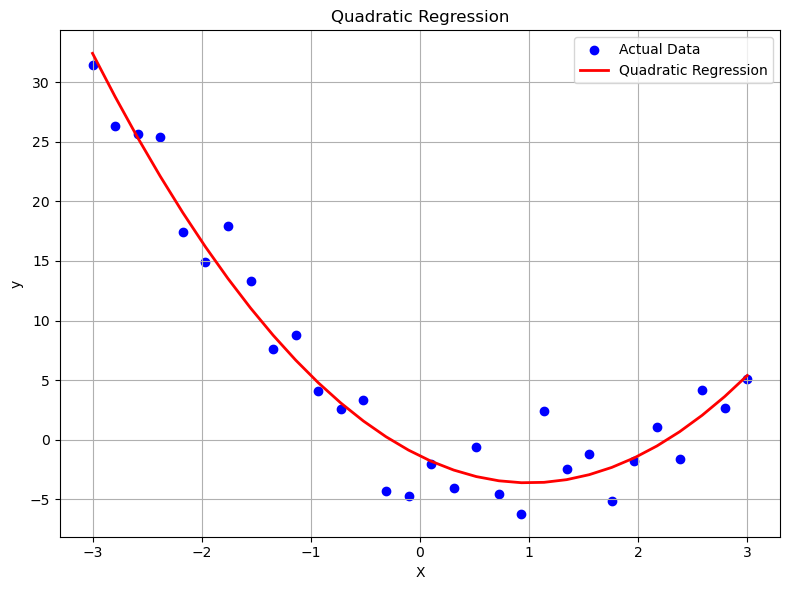

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic dataset
X = np.linspace(-3, 3, 30)  # Keep as 1D for plotting
y = 2 * X**2 - 4 * X + np.random.normal(0, 3, 30)  # 1D array

# Reshape X to 2D for sklearn (model expects 2D input)
X_2d = X.reshape(-1, 1)

# Polynomial transformation (degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_2d)

# Train quadratic regression model
model = LinearRegression()
model.fit(X_poly, y)
y_pred = model.predict(X_poly)

# Evaluate model
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

# Print results
print(f"{'Root Mean Squared Error':<20} {rmse:.2f}")
print(f"{'R-Squared Score':<20} {r2:.2f}")

# Plot results
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Actual Data')  # Use 1D X and y
plt.plot(X, y_pred, color='red', linewidth=2, label='Quadratic Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Quadratic Regression')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Root Mean Squared Error 2.38
R-Squared Score      0.99


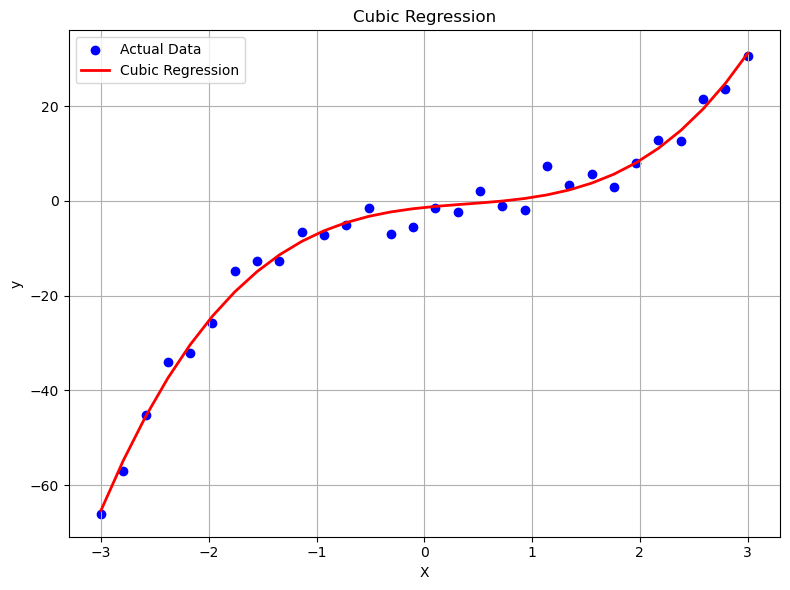

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic dataset (cubic relationship)
X = np.linspace(-3, 3, 30)
y = 1.5 * X**3 - 2 * X**2 + 3 * X + np.random.normal(0, 3, 30)

# Reshape X for sklearn compatibility
X = X.reshape(-1, 1)
y = y.reshape(-1, 1)

# Apply polynomial transformation (cubic regression)
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

# Train the model
model = LinearRegression()
model.fit(X_poly, y)
y_pred = model.predict(X_poly)

# Model evaluation
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

#print(f'Root Mean Squared Error: {rmse:.2f}')
# Print results
print(f"{'Root Mean Squared Error':<20} {rmse:.2f}")
print(f"{'R-Squared Score':<20} {r2:.2f}")

# Plot results
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Actual Data')  # Use 1D X and y
plt.plot(X, y_pred, color='red', linewidth=2, label='Cubic Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Cubic Regression')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

